In [1]:
!pip install protobuf==5.29.1 numpy==2.0.0
!pip install mediapipe opencv-python matplotlib

  Using cached protobuf-5.29.1-cp38-abi3-manylinux2014_x86_64.whl.metadata (592 bytes)
  Using cached numpy-2.0.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
Using cached protobuf-5.29.1-cp38-abi3-manylinux2014_x86_64.whl (319 kB)
Using cached numpy-2.0.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (19.3 MB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.7
    Uninstalling protobuf-4.25.7:
      Successfully uninstalled protobuf-4.25.7
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.21 requires numpy<2, but you have numpy 2.0.0 which is incompatible.
mediapipe 0.10.21 requires protobuf<5,>=4.25.3, but you have protobuf 

In [6]:
# Step 1: Upload video
uploaded = files.upload()
video_path = list(uploaded.keys())[0]
print(f"Uploaded video: {video_path}")


Saving video 1.mp4 to video 1 (1).mp4
Uploaded video: video 1 (1).mp4


In [2]:
from google.colab import files
import mediapipe as mp
import cv2
import numpy as np
import matplotlib.pyplot as plt




In [3]:
#Initialize MediaPipe Pose
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils
pose = mp_pose.Pose(static_image_mode=False, min_detection_confidence=0.5)

In [7]:
#Load video and process frames
cap = cv2.VideoCapture(video_path)

frame_count = 0
hip_y_positions = []

In [8]:
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = pose.process(frame_rgb)

    if results.pose_landmarks:
        # Track the left hip (landmark index 23)
        left_hip = results.pose_landmarks.landmark[mp_pose.PoseLandmark.LEFT_HIP]
        hip_y_positions.append(left_hip.y)  # Normalized Y position (0–1)

        # Optionally, draw landmarks on the frame for visualization
        mp_drawing.draw_landmarks(frame, results.pose_landmarks, mp_pose.POSE_CONNECTIONS)

    frame_count += 1

cap.release()


In [9]:
#Compute normalized jump height
if len(hip_y_positions) > 0:
    min_y = min(hip_y_positions)
    max_y = max(hip_y_positions)
    jump_height_norm = max_y - min_y  # Normalized units

    print(f"Normalized Jump Height (Hip): {jump_height_norm:.4f}")
else:
    print("No landmarks detected.")

Normalized Jump Height (Hip): 0.2191


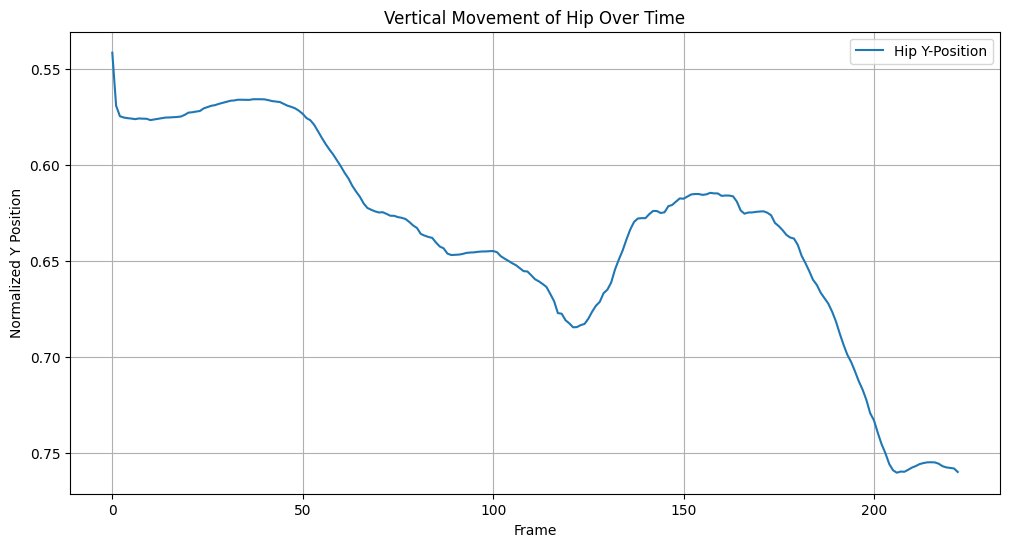

In [10]:
# Step 5: Plot the vertical movement of the hip
plt.figure(figsize=(12, 6))
plt.plot(hip_y_positions, label="Hip Y-Position")
plt.gca().invert_yaxis()  # Invert Y-axis for proper visualization
plt.title("Vertical Movement of Hip Over Time")
plt.xlabel("Frame")
plt.ylabel("Normalized Y Position")
plt.legend()
plt.grid()
plt.show()